# EEG Biometric Classification — TangentSpace + LDA

Pipeline: raw epochs → OAS covariance → Riemannian tangent space → LDA

**Same-session split**: first half of each recording = train, second half = test.  
This controls for session conditions — any separation is purely biometric.

In [1]:
import sys; sys.path.insert(0, '/home/josua/Projects/hackathon_zeiss/brain_id')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from pyriemann.tangentspace import TangentSpace
from pyriemann.estimation import Covariances
from riemann_potato import load_csv, preprocess, epoch, OCC_CHANNELS, RATE_TO_FREQ

INTERIM      = '../data/interim/'
INTERIM_10HZ = '../data/interim/10hz/'

PATHS = {
    ('ziyang', '1400', '10hz'): f'{INTERIM_10HZ}1400_ziyang_10hz.csv',
    ('ziyang', '1400', '15hz'): f'{INTERIM}1400_ziyang_15hz.csv',
    ('chris',  '1400', '10hz'): f'{INTERIM_10HZ}1400_chris_10hz.csv',
    ('chris',  '1400', '15hz'): f'{INTERIM}1400_chris_15hz.csv',
    ('chris',  '1600', '10hz'): f'{INTERIM_10HZ}1600_chris_10hz.csv',
    ('josua',  '1600', '10hz'): f'{INTERIM_10HZ}1600_josua_10hz.csv',
}

SUBJECT_COLORS = {'ziyang': '#1565C0', 'chris': '#EF5350', 'josua': '#2E7D32'}

SESSIONS = [
    ('1400', ['ziyang', 'chris'], ['10hz', '15hz']),
    ('1600', ['chris',  'josua'], ['10hz']),
]

def load_epochs_raw(path, ssvep_freq):
    """CSV -> (n_epochs, n_channels, n_times) ready for Covariances()."""
    X = load_csv(path, OCC_CHANNELS)
    X = preprocess(X, ssvep_freq)
    return epoch(X)

clf = Pipeline([
    ('cov', Covariances(estimator='oas')),
    ('ts',  TangentSpace(metric='riemann')),
    ('lda', LDA(solver='lsqr', shrinkage='auto')),
])

print('imports ok')

imports ok


## 1. Classification results — all sessions × rates

In [2]:
all_rows = []

for session, subjects, rates in SESSIONS:
    for rate in rates:
        ssvep_freq = RATE_TO_FREQ[rate]
        label_map  = {s: i for i, s in enumerate(subjects)}

        X_train, y_train = [], []
        X_test,  y_test  = [], []
        test_names = []

        for subj in subjects:
            eps = load_epochs_raw(PATHS[(subj, session, rate)], ssvep_freq)
            mid = len(eps) // 2
            X_train.append(eps[:mid]);  y_train.extend([label_map[subj]] * mid)
            X_test.append(eps[mid:]);   y_test.extend([label_map[subj]] * (len(eps) - mid))
            test_names.extend([subj] * (len(eps) - mid))

        X_train = np.concatenate(X_train); y_train = np.array(y_train)
        X_test  = np.concatenate(X_test);  y_test  = np.array(y_test)
        test_names = np.array(test_names)

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        print(f'=== Session {session}  {rate}  ({" vs ".join(subjects)}) ===')
        print(f'Train: {len(X_train)} epochs | Test: {len(X_test)} epochs')
        print(classification_report(y_test, y_pred, target_names=subjects))

        for subj in subjects:
            mask = test_names == subj
            acc  = (y_pred[mask] == y_test[mask]).mean()
            all_rows.append({
                'session': session, 'rate': rate,
                'subject': subj, 'accuracy': round(acc, 3),
                'n_test':  int(mask.sum()),
            })

pd.DataFrame(all_rows)

=== Session 1400  10hz  (ziyang vs chris) ===
Train: 100 epochs | Test: 101 epochs
              precision    recall  f1-score   support

      ziyang       0.94      0.97      0.96        33
       chris       0.99      0.97      0.98        68

    accuracy                           0.97       101
   macro avg       0.96      0.97      0.97       101
weighted avg       0.97      0.97      0.97       101



=== Session 1400  15hz  (ziyang vs chris) ===
Train: 94 epochs | Test: 96 epochs
              precision    recall  f1-score   support

      ziyang       0.54      0.47      0.50        32
       chris       0.75      0.80      0.77        64

    accuracy                           0.69        96
   macro avg       0.64      0.63      0.64        96
weighted avg       0.68      0.69      0.68        96



=== Session 1600  10hz  (chris vs josua) ===
Train: 76 epochs | Test: 77 epochs
              precision    recall  f1-score   support

       chris       1.00      0.92      0.96        38
       josua       0.93      1.00      0.96        39

    accuracy                           0.96        77
   macro avg       0.96      0.96      0.96        77
weighted avg       0.96      0.96      0.96        77



,session,rate,subject,accuracy,n_test
0,1400,10hz,ziyang,0.970,33
1,1400,10hz,chris,0.971,68
2,1400,15hz,ziyang,0.469,32
3,1400,15hz,chris,0.797,64
4,1600,10hz,chris,0.921,38
5,1600,10hz,josua,1.000,39


## 2. Confusion matrices

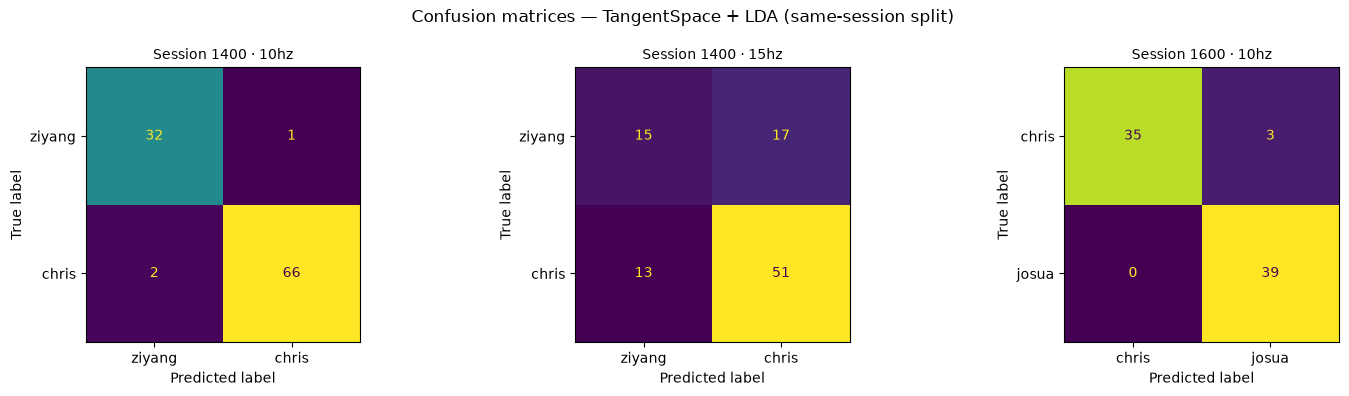

In [3]:
n_plots = sum(len(rates) for _, _, rates in SESSIONS)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
fig.suptitle('Confusion matrices — TangentSpace + LDA (same-session split)', fontsize=12)

ax_idx = 0
for session, subjects, rates in SESSIONS:
    for rate in rates:
        ssvep_freq = RATE_TO_FREQ[rate]
        label_map  = {s: i for i, s in enumerate(subjects)}
        X_train, y_train, X_test, y_test = [], [], [], []
        for subj in subjects:
            eps = load_epochs_raw(PATHS[(subj, session, rate)], ssvep_freq)
            mid = len(eps) // 2
            X_train.append(eps[:mid]);  y_train.extend([label_map[subj]] * mid)
            X_test.append(eps[mid:]);   y_test.extend([label_map[subj]] * (len(eps) - mid))
        X_train = np.concatenate(X_train); y_train = np.array(y_train)
        X_test  = np.concatenate(X_test);  y_test  = np.array(y_test)
        clf.fit(X_train, y_train)
        ConfusionMatrixDisplay.from_estimator(
            clf, X_test, y_test,
            display_labels=subjects, ax=axes[ax_idx], colorbar=False
        )
        axes[ax_idx].set_title(f'Session {session} · {rate}', fontsize=10)
        ax_idx += 1

plt.tight_layout()
plt.savefig('../reports/figures/18_lda_confusion_matrices.png', dpi=150)
plt.show()

## 3. Tangent space PCA — visualise class separation

2D PCA of tangent space vectors for session 1400 · 10 Hz. Circles = train, crosses = test.

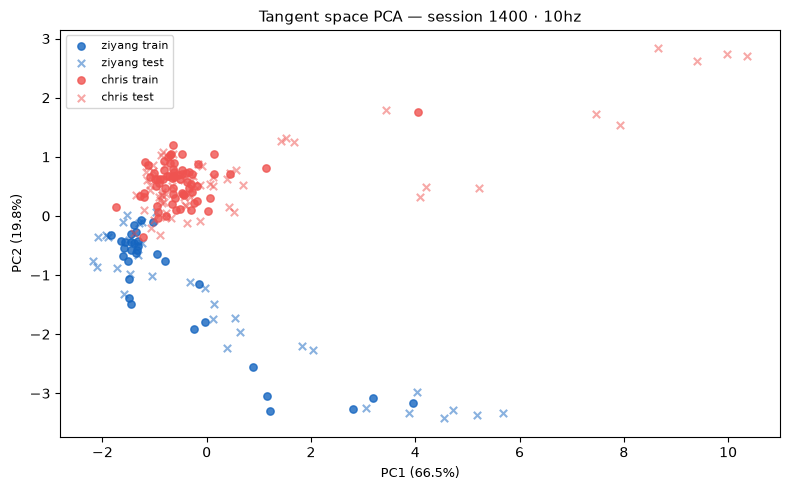

In [4]:
from sklearn.decomposition import PCA

session, subjects, rate = '1400', ['ziyang', 'chris'], '10hz'
ssvep_freq = RATE_TO_FREQ[rate]
label_map  = {s: i for i, s in enumerate(subjects)}

all_eps, y_all, is_train = [], [], []
for subj in subjects:
    eps = load_epochs_raw(PATHS[(subj, session, rate)], ssvep_freq)
    mid = len(eps) // 2
    all_eps.append(eps)
    y_all.extend([label_map[subj]] * len(eps))
    is_train.extend([True] * mid + [False] * (len(eps) - mid))

all_eps  = np.concatenate(all_eps)
y_all    = np.array(y_all)
is_train = np.array(is_train)

covs_all = Covariances(estimator='oas').fit_transform(all_eps)
ts_fit   = TangentSpace(metric='riemann').fit(covs_all)
vecs     = ts_fit.transform(covs_all)

pca = PCA(n_components=2)
pts = pca.fit_transform(vecs)
var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(f'Tangent space PCA — session {session} · {rate}', fontsize=11)
for i, subj in enumerate(subjects):
    mask = y_all == i
    ax.scatter(pts[mask & is_train,  0], pts[mask & is_train,  1],
               c=SUBJECT_COLORS[subj], marker='o', s=28, alpha=0.8, label=f'{subj} train')
    ax.scatter(pts[mask & ~is_train, 0], pts[mask & ~is_train, 1],
               c=SUBJECT_COLORS[subj], marker='x', s=28, alpha=0.5, label=f'{subj} test')
ax.set_xlabel(f'PC1 ({var[0]:.1f}%)', fontsize=9)
ax.set_ylabel(f'PC2 ({var[1]:.1f}%)', fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/19_lda_tangentspace_pca.png', dpi=150)
plt.show()

## 4. Session 2000 — all 6 pairwise comparisons (10 Hz)

4 subjects: ziyang, chris, josua, mehak. Every possible pair tested with the same split protocol.

In [5]:
from itertools import combinations

SUBJECTS_2000 = ['ziyang', 'chris', 'josua', 'mehak']
COLORS_2000   = {'ziyang': '#1565C0', 'chris': '#EF5350', 'josua': '#2E7D32', 'mehak': '#FF6F00'}
PATHS_2000    = {s: f'{INTERIM_10HZ}2000_{s}_10hz.csv' for s in SUBJECTS_2000}
SSVEP_FREQ    = RATE_TO_FREQ['10hz']

pairs = list(combinations(SUBJECTS_2000, 2))
pair_acc = {}

for subj_a, subj_b in pairs:
    subjects = [subj_a, subj_b]
    label_map = {s: i for i, s in enumerate(subjects)}
    X_train, y_train, X_test, y_test = [], [], [], []
    for subj in subjects:
        eps = load_epochs_raw(PATHS_2000[subj], SSVEP_FREQ)
        mid = len(eps) // 2
        X_train.append(eps[:mid]);  y_train.extend([label_map[subj]] * mid)
        X_test.append(eps[mid:]);   y_test.extend([label_map[subj]] * (len(eps) - mid))
    X_train = np.concatenate(X_train); y_train = np.array(y_train)
    X_test  = np.concatenate(X_test);  y_test  = np.array(y_test)
    clf.fit(X_train, y_train)
    acc = (clf.predict(X_test) == y_test).mean()
    pair_acc[(subj_a, subj_b)] = round(acc, 3)
    print(f'{subj_a:8s} vs {subj_b:8s}  →  accuracy {acc:.1%}')

print(f'\nMean pairwise accuracy: {np.mean(list(pair_acc.values())):.1%}')

ziyang   vs chris     →  accuracy 87.8%
ziyang   vs josua     →  accuracy 100.0%
ziyang   vs mehak     →  accuracy 79.1%


chris    vs josua     →  accuracy 100.0%
chris    vs mehak     →  accuracy 95.1%
josua    vs mehak     →  accuracy 100.0%

Mean pairwise accuracy: 93.7%


## 5. Session 2000 — 4-class classification

All 4 subjects in one model. Train on first half of everyone, test on second half.

4-class accuracy: 85.1%

              precision    recall  f1-score   support

      ziyang       1.00      0.59      0.74        34
       chris       0.84      0.90      0.87        48
       josua       1.00      1.00      1.00        33
       mehak       0.68      0.91      0.78        33

    accuracy                           0.85       148
   macro avg       0.88      0.85      0.85       148
weighted avg       0.88      0.85      0.85       148



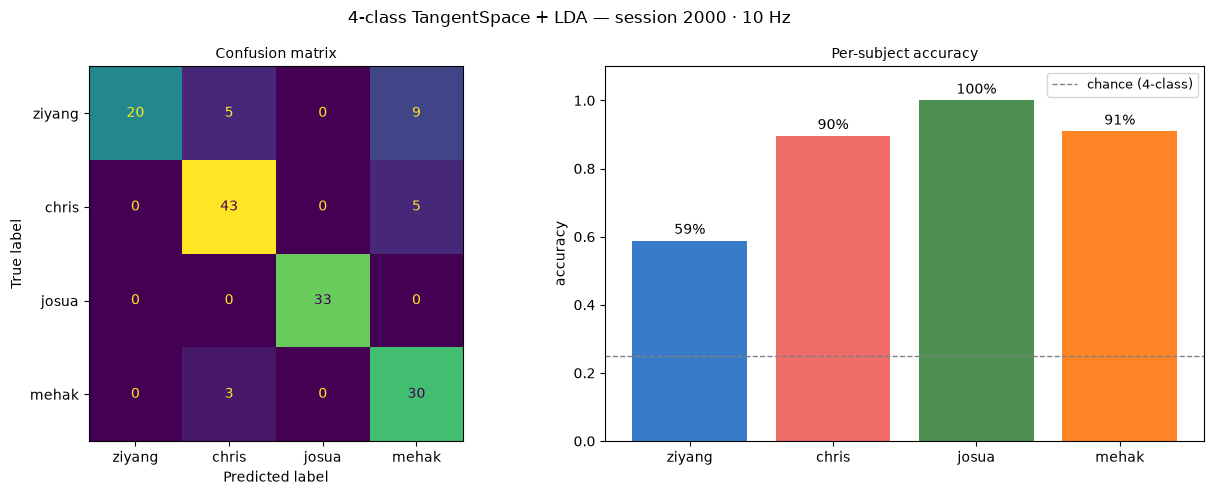

In [6]:
label_map = {s: i for i, s in enumerate(SUBJECTS_2000)}
X_train, y_train, X_test, y_test, test_names = [], [], [], [], []

for subj in SUBJECTS_2000:
    eps = load_epochs_raw(PATHS_2000[subj], SSVEP_FREQ)
    mid = len(eps) // 2
    X_train.append(eps[:mid]);  y_train.extend([label_map[subj]] * mid)
    X_test.append(eps[mid:]);   y_test.extend([label_map[subj]] * (len(eps) - mid))
    test_names.extend([subj] * (len(eps) - mid))

X_train = np.concatenate(X_train); y_train = np.array(y_train)
X_test  = np.concatenate(X_test);  y_test  = np.array(y_test)
test_names = np.array(test_names)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(f'4-class accuracy: {(y_pred == y_test).mean():.1%}\n')
print(classification_report(y_test, y_pred, target_names=SUBJECTS_2000))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('4-class TangentSpace + LDA — session 2000 · 10 Hz', fontsize=12)

ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=SUBJECTS_2000,
    ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion matrix', fontsize=10)

# Per-subject accuracy bar chart
accs = [(subj, (y_pred[test_names == subj] == y_test[test_names == subj]).mean())
        for subj in SUBJECTS_2000]
colors_bar = [COLORS_2000[s] for s, _ in accs]
axes[1].bar([s for s, _ in accs], [a for _, a in accs], color=colors_bar, alpha=0.85)
axes[1].axhline(0.25, color='grey', linestyle='--', linewidth=1, label='chance (4-class)')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('accuracy')
axes[1].set_title('Per-subject accuracy', fontsize=10)
for i, (subj, acc) in enumerate(accs):
    axes[1].text(i, acc + 0.02, f'{acc:.0%}', ha='center', fontsize=10)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/20_lda_4class_2000session.png', dpi=150)
plt.show()

---
## 6. Epoch length comparison — 2 s vs 4 s (session 2000 · 10 Hz)

Longer epochs → more samples per covariance estimate → lower noise → tighter clusters.  
Trade-off: fewer epochs available for training/testing.  
Everything else identical to sections 4 & 5.

In [7]:
from scipy.signal import detrend as sp_detrend
import riemann_potato as rp

def epoch_sec(X, sec, sfreq=rp.SFREQ_DS, overlap=rp.OVERLAP):
    """Same logic as riemann_potato.epoch() but with configurable window length."""
    n    = int(sec * sfreq)
    step = max(1, int(n * (1 - overlap)))
    eps  = np.stack([X[:, s:s+n] for s in range(0, X.shape[1]-n+1, step)])
    eps  = sp_detrend(eps, axis=2)
    keep = np.abs(eps).max(axis=(1, 2)) < rp.ARTIFACT_NV
    return eps[keep]

def load_epochs_sec(path, ssvep_freq, sec):
    X = load_csv(path, OCC_CHANNELS)
    X = preprocess(X, ssvep_freq)
    return epoch_sec(X, sec)

EPOCH_LENGTHS = [2.0, 4.0]
comparison_rows = []

for sec in EPOCH_LENGTHS:
    pair_accs = {}
    for subj_a, subj_b in pairs:
        subjects  = [subj_a, subj_b]
        label_map = {s: i for i, s in enumerate(subjects)}
        Xtr, ytr, Xte, yte = [], [], [], []
        for s in subjects:
            eps = load_epochs_sec(PATHS_2000[s], SSVEP_FREQ, sec)
            mid = len(eps) // 2
            Xtr.append(eps[:mid]); ytr.extend([label_map[s]] * mid)
            Xte.append(eps[mid:]); yte.extend([label_map[s]] * (len(eps) - mid))
        Xtr = np.concatenate(Xtr); ytr = np.array(ytr)
        Xte = np.concatenate(Xte); yte = np.array(yte)
        clf.fit(Xtr, ytr)
        acc = (clf.predict(Xte) == yte).mean()
        pair_accs[(subj_a, subj_b)] = acc
        comparison_rows.append({
            'epoch_sec': sec, 'pair': f'{subj_a} vs {subj_b}',
            'accuracy': round(acc, 3),
            'n_train': len(Xtr) // 2, 'n_test': len(Xte) // 2,
        })

    # 4-class
    label_map = {s: i for i, s in enumerate(SUBJECTS_2000)}
    Xtr, ytr, Xte, yte = [], [], [], []
    for s in SUBJECTS_2000:
        eps = load_epochs_sec(PATHS_2000[s], SSVEP_FREQ, sec)
        mid = len(eps) // 2
        Xtr.append(eps[:mid]); ytr.extend([label_map[s]] * mid)
        Xte.append(eps[mid:]); yte.extend([label_map[s]] * (len(eps) - mid))
    Xtr = np.concatenate(Xtr); ytr = np.array(ytr)
    Xte = np.concatenate(Xte); yte = np.array(yte)
    clf.fit(Xtr, ytr)
    acc4 = (clf.predict(Xte) == yte).mean()
    comparison_rows.append({
        'epoch_sec': sec, 'pair': '4-class',
        'accuracy': round(acc4, 3),
        'n_train': len(Xtr) // 4, 'n_test': len(Xte) // 4,
    })

df_cmp = pd.DataFrame(comparison_rows)
df_cmp_wide = df_cmp.pivot(index='pair', columns='epoch_sec', values='accuracy')
df_cmp_wide['delta'] = (df_cmp_wide[4.0] - df_cmp_wide[2.0]).round(3)
df_cmp_wide.columns = ['2 s accuracy', '4 s accuracy', 'Δ (4s − 2s)']

def color_delta(val):
    if val > 0:   return 'background-color: #c8e6c9'
    if val < 0:   return 'background-color: #ffcdd2'
    return ''

df_cmp_wide.style.map(color_delta, subset=['Δ (4s − 2s)'])

,2 s accuracy,4 s accuracy,Δ (4s − 2s)
pair,,,
4-class,0.851000,0.877000,0.026000
chris vs josua,1.000000,1.000000,0.000000
chris vs mehak,0.951000,1.000000,0.049000
josua vs mehak,1.000000,1.000000,0.000000
ziyang vs chris,0.878000,0.951000,0.073000
ziyang vs josua,1.000000,1.000000,0.000000
ziyang vs mehak,0.791000,0.818000,0.027000


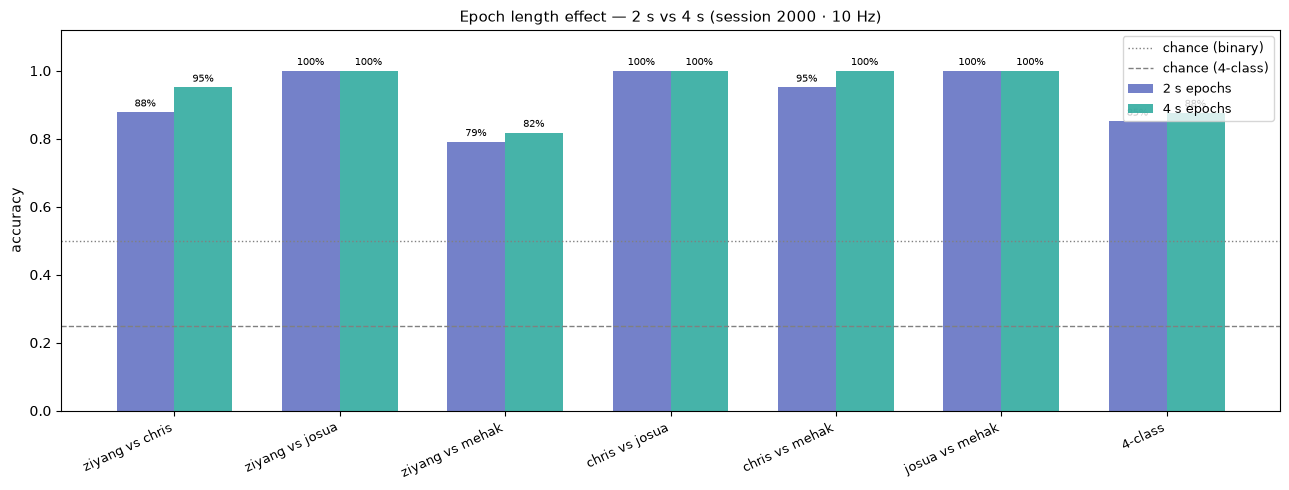

In [8]:
# Bar chart: 2s vs 4s side by side per pair
pair_labels = [f'{a} vs {b}' for a, b in pairs] + ['4-class']
x = np.arange(len(pair_labels))
w = 0.35

accs_2s = [df_cmp_wide.loc[p, '2 s accuracy'] for p in pair_labels]
accs_4s = [df_cmp_wide.loc[p, '4 s accuracy'] for p in pair_labels]

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, accs_2s, w, label='2 s epochs', color='#5C6BC0', alpha=0.85)
b2 = ax.bar(x + w/2, accs_4s, w, label='4 s epochs', color='#26A69A', alpha=0.85)
ax.axhline(0.5,  color='grey',  linestyle=':', linewidth=1, label='chance (binary)')
ax.axhline(0.25, color='grey',  linestyle='--', linewidth=1, label='chance (4-class)')
ax.set_xticks(x); ax.set_xticklabels(pair_labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('accuracy'); ax.set_ylim(0, 1.12)
ax.set_title('Epoch length effect — 2 s vs 4 s (session 2000 · 10 Hz)', fontsize=11)
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}',
            ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('../reports/figures/21_epoch_length_comparison.png', dpi=150)
plt.show()